PHASE 1: SETUP

Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


YOUR PARAMETERS (MANDATORY)

In [20]:
# Roll No: 102303792

window_size = 15
prediction_horizon = 3
hidden_size = 14

PHASE 2: DATA + WINDOWING

Simple Dataset (for understanding)

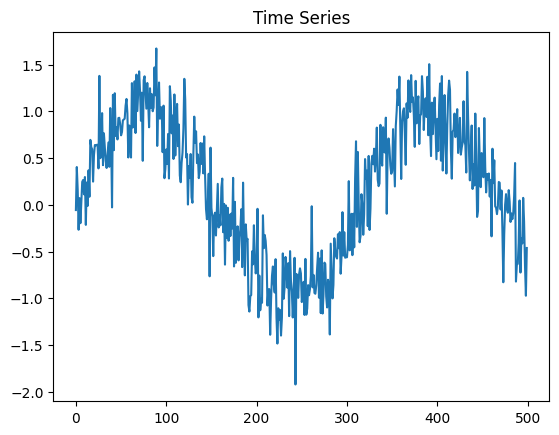

In [21]:
t = np.arange(0, 500)
data = np.sin(0.02*t) + 0.3*np.random.randn(500)

plt.plot(data)
plt.title("Time Series")
plt.show()

Windowing Function (CORE)

In [22]:
def create_sequences(data, window_size, horizon):
    X, y = [], []

    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

X, y = create_sequences(data, window_size, prediction_horizon)

print(X.shape, y.shape)

(482, 15) (482, 3)


Train-Test Split (Chronological)

In [23]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Dataset Classes

In [24]:
class DatasetMLP(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class DatasetRNN(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

DataLoaders

In [25]:
train_mlp = DataLoader(DatasetMLP(X_train, y_train), batch_size=32, shuffle=False)
test_mlp  = DataLoader(DatasetMLP(X_test, y_test), batch_size=32, shuffle=False)

train_rnn = DataLoader(DatasetRNN(X_train, y_train), batch_size=32, shuffle=False)
test_rnn  = DataLoader(DatasetRNN(X_test, y_test), batch_size=32, shuffle=False)

PHASE 3: MODELS

MLP (Baseline)

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, prediction_horizon)
        )

    def forward(self, x):
        return self.net(x)

Custom RNN (FROM SCRATCH)

In [27]:
class CustomRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.Wx = nn.Linear(1, hidden_size)
        self.Wh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, hidden_size).to(x.device)

        for t in range(seq_len):
            x_t = x[:, t, :]
            h = torch.tanh(self.Wx(x_t) + self.Wh(h))

        return self.fc(h)

TRAIN + EVAL FUNCTIONS

In [28]:
def train_model(model, loader, epochs=20):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        total = 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            optimizer.step()

            total += loss.item()

        losses.append(total/len(loader))

    return losses


def evaluate(model, loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            pred = model(Xb)

            preds.append(pred.cpu().numpy())
            actuals.append(yb.numpy())

    preds = np.concatenate(preds)
    actuals = np.concatenate(actuals)

    mse = mean_squared_error(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse, preds, actuals

TRAIN BOTH

In [29]:
mlp = MLP().to(device)
rnn = CustomRNN().to(device)

mlp_loss = train_model(mlp, train_mlp)
rnn_loss = train_model(rnn, train_rnn)

print("MLP:", evaluate(mlp, test_mlp)[:3])
print("RNN:", evaluate(rnn, test_rnn)[:3])

MLP: (0.11204496026039124, 0.2649994194507599, np.float64(0.33473117611060854))
RNN: (0.14721062779426575, 0.31063148379325867, np.float64(0.3836803719168675))


PHASE 4: LSTM + TRANSFORMER

LSTM

In [31]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

Transformer

In [32]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(1, hidden_size)

        layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=2,
            batch_first=True
        )

        self.trans = nn.TransformerEncoder(layer, num_layers=1)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        x = self.embed(x)
        x = self.trans(x)
        return self.fc(x[:, -1, :])

PHASE 5: RESULTS + PLOTS

Plot loss

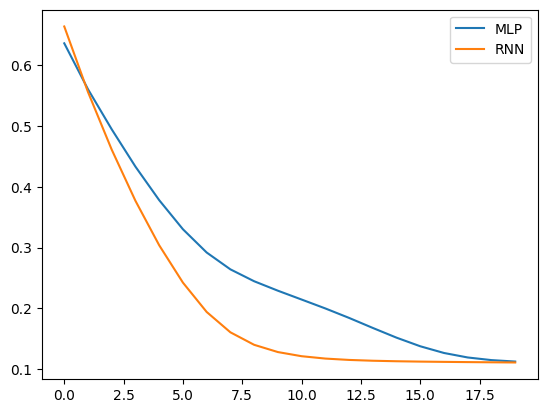

In [33]:
plt.plot(mlp_loss, label="MLP")
plt.plot(rnn_loss, label="RNN")
plt.legend()
plt.show()

Prediction vs Actual

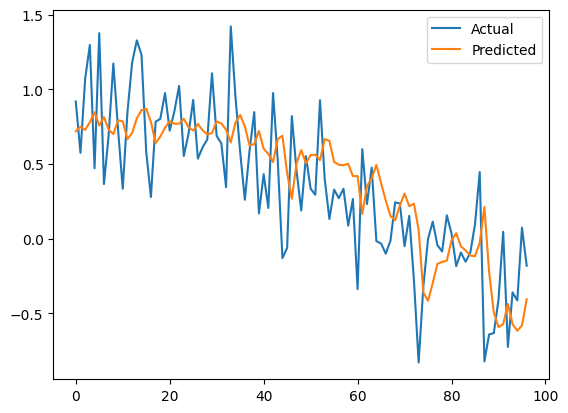

In [34]:
mse, mae, rmse, preds, actuals = evaluate(rnn, test_rnn)

plt.plot(actuals[:,0], label="Actual")
plt.plot(preds[:,0], label="Predicted")
plt.legend()
plt.show()

FINAL STEP: ABLATION

Case 1: Original

In [35]:
window_size = 15

Case 2: Half

In [36]:
window_size = 7

Case 3: Double

In [37]:
window_size = 30

Step 1: Create a function for one run

In [38]:
def run_experiment(window_size, data, prediction_horizon):
    print(f"\nRunning for window_size = {window_size}")

    # 1. Create sequences
    X, y = create_sequences(data, window_size, prediction_horizon)

    # 2. Train-test split (chronological)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # 3. Dataset + DataLoader
    train_loader = DataLoader(DatasetRNN(X_train, y_train), batch_size=32, shuffle=False)
    test_loader  = DataLoader(DatasetRNN(X_test, y_test), batch_size=32, shuffle=False)

    # 4. Reinitialize model (VERY IMPORTANT)
    model = CustomRNN().to(device)

    # 5. Train
    losses = train_model(model, train_loader, epochs=20)

    # 6. Evaluate
    mse, mae, rmse, preds, actuals = evaluate(model, test_loader)

    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    # 7. Plot loss
    plt.figure()
    plt.plot(losses)
    plt.title(f"Loss (window={window_size})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # 8. Plot predictions
    plt.figure(figsize=(10,5))
    plt.plot(actuals[:,0], label="Actual")
    plt.plot(preds[:,0], label="Predicted")
    plt.title(f"Prediction vs Actual (window={window_size})")
    plt.legend()
    plt.show()

    return mse, mae, rmse

Step 2: Run Ablation (ALL 3 CASES)


Running for window_size = 15
MSE: 0.1483, MAE: 0.3139, RMSE: 0.3850


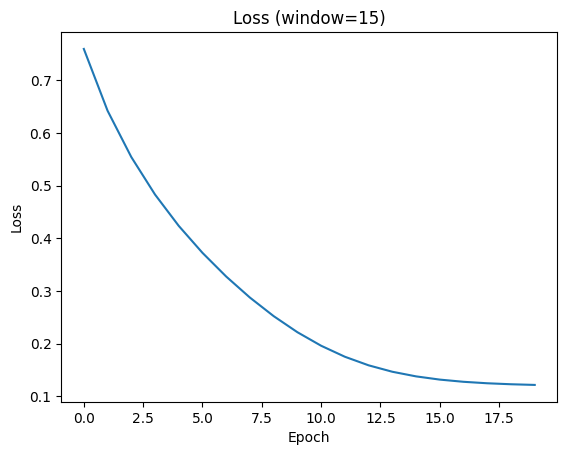

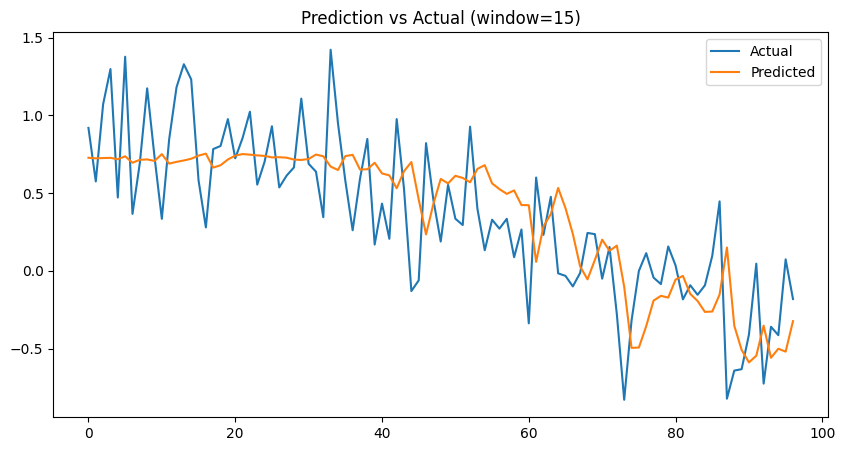


Running for window_size = 7
MSE: 0.1321, MAE: 0.3007, RMSE: 0.3634


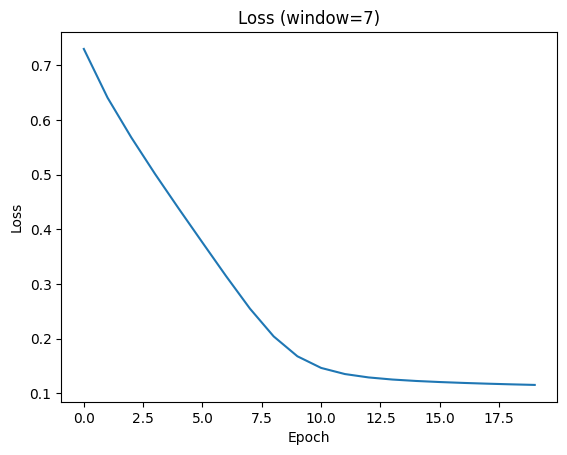

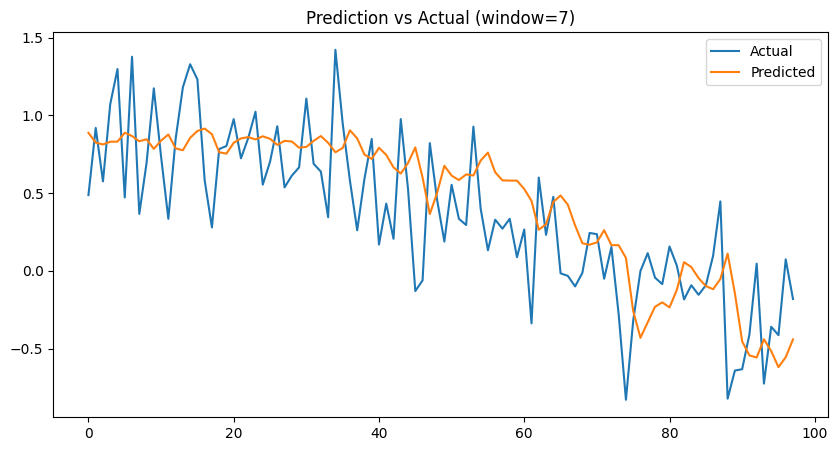


Running for window_size = 30
MSE: 0.1591, MAE: 0.3246, RMSE: 0.3988


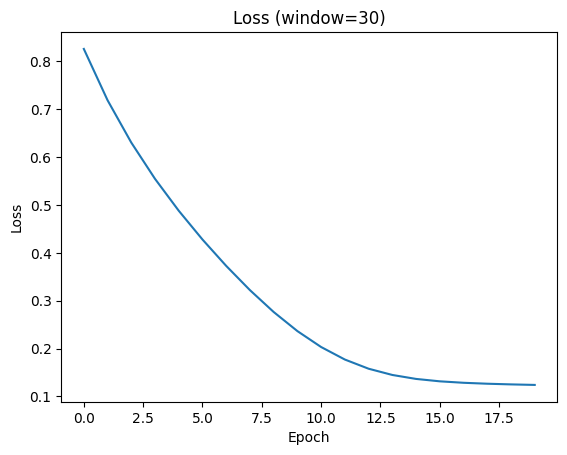

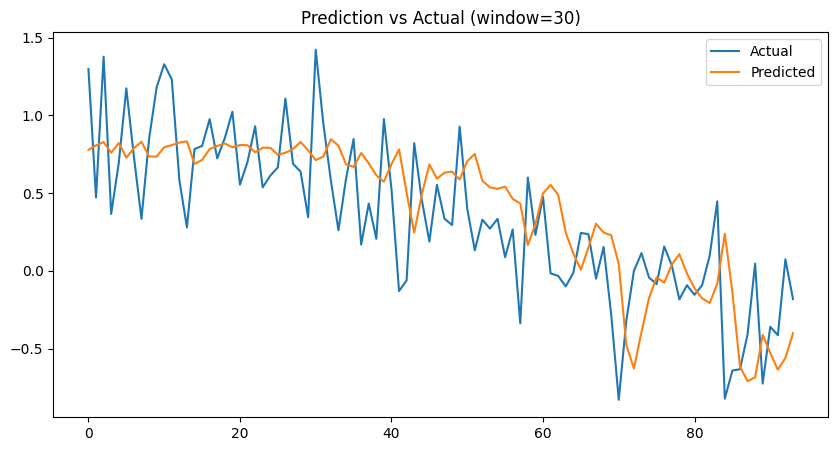

In [39]:
results = {}

for w in [15, 7, 30]:   # original, half, double
    mse, mae, rmse = run_experiment(w, data, prediction_horizon)
    results[w] = (mse, mae, rmse)

Step 3: Print Comparison Table

In [40]:
print("\nFinal Comparison:")

for w, (mse, mae, rmse) in results.items():
    print(f"Window {w} → MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")


Final Comparison:
Window 15 → MSE: 0.1483, MAE: 0.3139, RMSE: 0.3850
Window 7 → MSE: 0.1321, MAE: 0.3007, RMSE: 0.3634
Window 30 → MSE: 0.1591, MAE: 0.3246, RMSE: 0.3988


(DATASET 2 – ELECTRICITY)

SECTION 1: Upload + Load Dataset



In [42]:
print("===== ELECTRICITY DATASET =====")

from google.colab import files
uploaded = files.upload()   # upload your CSV file here

import pandas as pd
import numpy as np

# Read uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Columns:", df.columns)
df.head()

===== ELECTRICITY DATASET =====


Saving Electric_Production.csv to Electric_Production.csv
Columns: Index(['DATE', 'Value'], dtype='object')


,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


SECTION 2: Extract Time Series

In [43]:
# Select first numeric column automatically
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) == 0:
    raise ValueError("No numeric column found!")

col = numeric_cols[0]
print("Using column:", col)

data2 = df[col].dropna().values.astype(np.float32)

Using column: Value


SECTION 3: Normalize Data

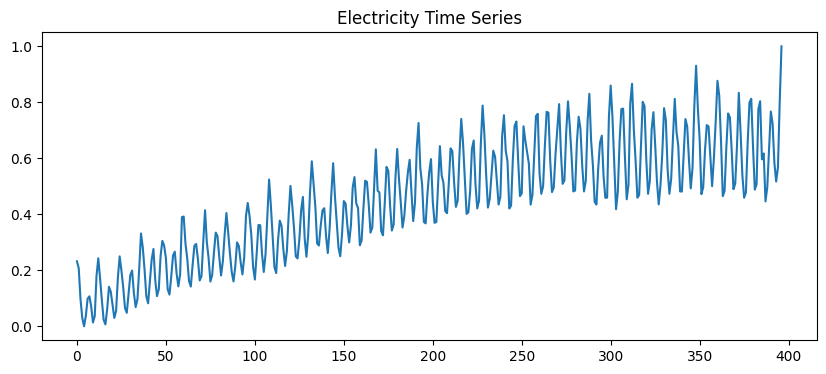

In [44]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

scaler2 = MinMaxScaler()
data2 = scaler2.fit_transform(data2.reshape(-1,1)).flatten()

# Plot sample
plt.figure(figsize=(10,4))
plt.plot(data2[:500])
plt.title("Electricity Time Series")
plt.show()

SECTION 4: Reusable Pipeline Function

In [45]:
def run_pipeline(data, window_size, name="Dataset"):

    print(f"\n[{name}] Window Size = {window_size}")

    # 1. Windowing
    X, y = create_sequences(data, window_size, prediction_horizon)

    # 2. Split (chronological)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # 3. DataLoader
    train_loader = DataLoader(DatasetRNN(X_train, y_train), batch_size=32, shuffle=False)
    test_loader  = DataLoader(DatasetRNN(X_test, y_test), batch_size=32, shuffle=False)

    # 4. Model (REINITIALIZED)
    model = CustomRNN().to(device)

    # 5. Train
    losses = train_model(model, train_loader)

    # 6. Evaluate
    mse, mae, rmse, preds, actuals = evaluate(model, test_loader)

    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    return losses, preds, actuals, mse, mae, rmse

SECTION 5: Ablation Study


[Electricity] Window Size = 15
MSE: 0.0381, MAE: 0.1578, RMSE: 0.1952


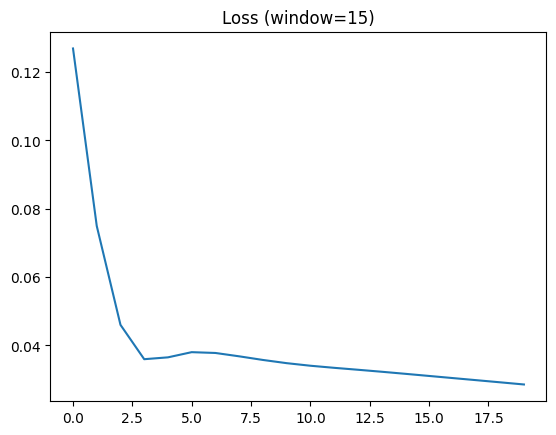


[Electricity] Window Size = 7
MSE: 0.0525, MAE: 0.1960, RMSE: 0.2292


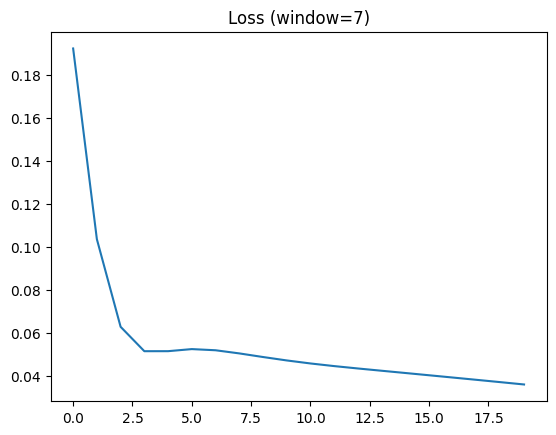


[Electricity] Window Size = 30
MSE: 0.0318, MAE: 0.1443, RMSE: 0.1784


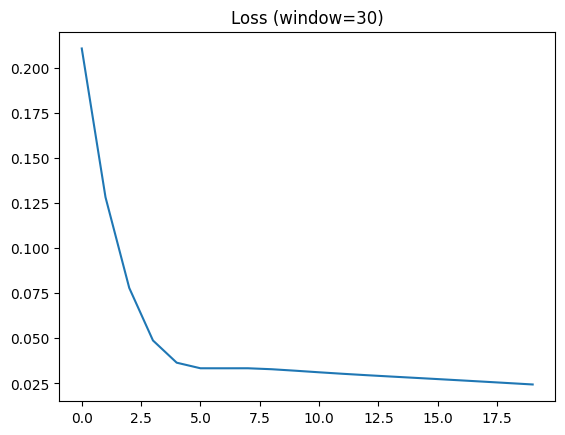

In [46]:
results2 = {}
pred_store = {}

for w in [15, 7, 30]:

    losses, preds, actuals, mse, mae, rmse = run_pipeline(data2, w, "Electricity")

    results2[w] = (mse, mae, rmse)
    pred_store[w] = (preds, actuals)

    # Plot loss
    plt.figure()
    plt.plot(losses)
    plt.title(f"Loss (window={w})")
    plt.show()

SECTION 6: Prediction vs Actual

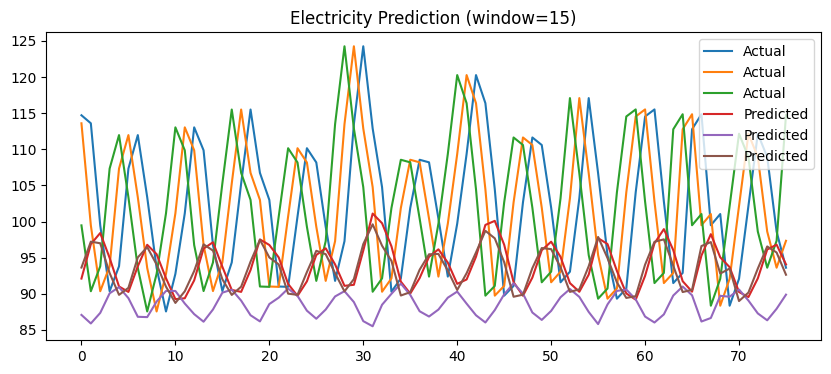

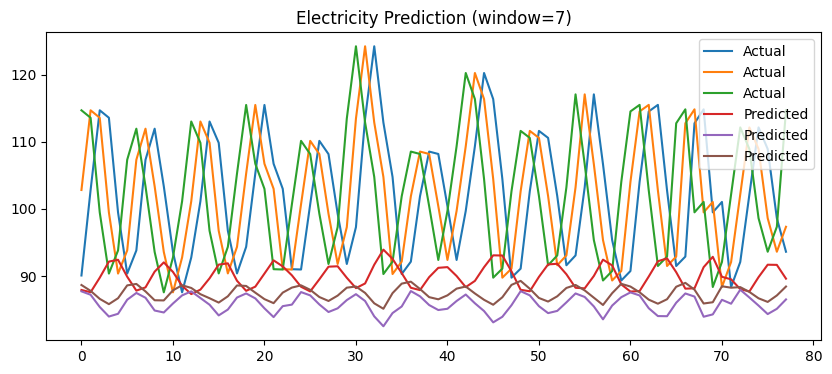

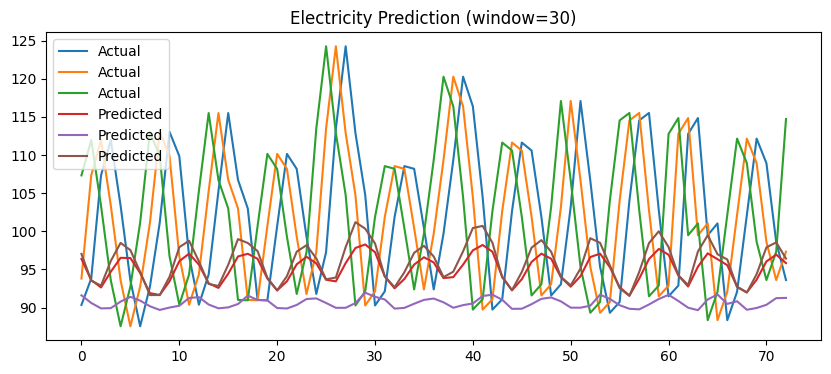

In [47]:
for w in [15, 7, 30]:

    preds, actuals = pred_store[w]

    preds_inv = scaler2.inverse_transform(preds)
    actuals_inv = scaler2.inverse_transform(actuals)

    plt.figure(figsize=(10,4))
    plt.plot(actuals_inv[:200], label="Actual")
    plt.plot(preds_inv[:200], label="Predicted")
    plt.title(f"Electricity Prediction (window={w})")
    plt.legend()
    plt.show()

SECTION 7: Final Comparison Table

In [48]:
print("\n===== ELECTRICITY DATASET RESULTS =====")

for w, (mse, mae, rmse) in results2.items():
    print(f"Window {w} → MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")


===== ELECTRICITY DATASET RESULTS =====
Window 15 → MSE: 0.0381, MAE: 0.1578, RMSE: 0.1952
Window 7 → MSE: 0.0525, MAE: 0.1960, RMSE: 0.2292
Window 30 → MSE: 0.0318, MAE: 0.1443, RMSE: 0.1784
